---
title: Nino indices from HadISST data
author: Harsha R. Hampapura
date: 25-02-2026
---

:::{hint}
For a great introduction to Nino indices, see [the climate data guide](https://climatedataguide.ucar.edu/climate-data/nino-sst-indices-nino-12-3-34-4-oni-and-tni?utm_source=chatgpt.com)
:::

## Section 1: Introduction
- This notebook illustrates how to compute and plot various Nino indices using the HadISST dataset hosted on NCAR's Geoscience Data Exchange (GDEX)
- Python package imports and useful function definitions

In [1]:
# Import
import intake
import numpy as np
import xarray as xr
import nc_time_axis
import os
import matplotlib.pyplot as plt
import fsspec

In [2]:
import dask 
from dask_jobqueue import PBSCluster
from dask.distributed import Client
from dask.distributed import performance_report

In [4]:
#### Useful function ###
def area_mean(da):
    """
    Area-weighted mean over lat/lon using cos(lat) weighting.
    Assumes da has dims including lat, lon.
    """
    weights = np.cos(np.deg2rad(da["latitude"]))
    weights.name = "weights"
    return da.weighted(weights).mean(dim=("latitude", "longitude"), skipna=True)

def lon_to_360(da):
    """Ensure longitude is [0, 360) and sorted.""" 
    lon_name = "lon" if "lon" in da.coords else "longitude"
    lon = da[lon_name]
    lon360 = (lon % 360)   
    #The above logic is tricky for negative divisors or dividends and is not guaranteed to work in other programming languages
    #For more details, see https://en.wikipedia.org/wiki/Modulo
    da = da.assign_coords({lon_name: lon360}).sortby(lon_name)
    return da

In [5]:
##
def nino_index_series(sst, region):
    lat0, lat1 = region["latitude"]
    lon0, lon1 = region["longitude"]
    sub = sst.sel(latitude=slice(lat0, lat1), longitude=slice(lon0, lon1))
    return area_mean(sub)

## Section 2: Select Dask Cluster

#### Select the Dask cluster type
The default will be LocalCluster as that can run on any system.

If running on a HPC computer with a PBS Scheduler, set to True. Otherwise, set to False.

In [ ]:
USE_PBS_SCHEDULER = False

If running on Jupyter server with Dask Gateway configured, set to True. Otherwise, set to False.

In [5]:
USE_DASK_GATEWAY = False

#### Python function for a PBS cluster

In [ ]:
# Create a PBS cluster object
def get_pbs_cluster():
    """ Create cluster through dask_jobqueue.   
    """
    # Set up your scratch folder path
    username       = os.environ["USER"]
    glade_scratch  = "/glade/derecho/scratch/" + username
    print(glade_scratch)
    from dask_jobqueue import PBSCluster
    cluster = PBSCluster(
        job_name = 'dask-osdf-24',
        cores = 1,
        memory = '4GiB',
        processes = 1,
        local_directory = lustre_scratch + '/dask/spill',
        log_directory = lustre_scratch + '/dask/logs/',
        resource_spec = 'select=1:ncpus=1:mem=4GB',
        queue = 'casper',
        walltime = '3:00:00',
        #interface = 'ib0'
        interface = 'ext'
    )
    return cluster

#### Python function for a Gateway Cluster

In [7]:
def get_gateway_cluster():
    """ Create cluster through dask_gateway
    """
    from dask_gateway import Gateway

    gateway = Gateway()
    cluster = gateway.new_cluster()
    cluster.adapt(minimum=2, maximum=4)
    return cluster

In [8]:
def get_local_cluster():
    """ Create cluster using the Jupyter server's resources
    """
    from distributed import LocalCluster, performance_report
    cluster = LocalCluster()    

    cluster.scale(6)
    return cluster

#### Python logic for a Local Cluster
This uses True/False boolean logic based on the variables set in the previous cells

In [9]:
# Obtain dask cluster in one of three ways
if USE_PBS_SCHEDULER:
    cluster = get_pbs_cluster()
elif USE_DASK_GATEWAY:
    cluster = get_gateway_cluster()
else:
    cluster = get_local_cluster()

# Connect to cluster
from distributed import Client
client = Client(cluster)

In [10]:
# Scale the cluster and display cluster dashboard URL
n_workers =8
cluster.scale(n_workers)
client.wait_for_workers(n_workers = n_workers)
cluster

PBSCluster(bfdd887b, 'tcp://128.117.208.98:41657', workers=8, threads=8, memory=32.00 GiB)

## Section 3: Data Loading and transforms
- Load HadISST data from GDEX using xarray
- For more details regarding the dataset. See, https://gdex.ucar.edu/datasets/d277003/

In [11]:
import requests
import gzip 
import tempfile

url = "https://osdf-director.osg-htc.org/ncar/gdex/d277003/HadISST_sst.nc.gz"

r = requests.get(url)
r.raise_for_status()
raw_nc = gzip.decompress(r.content)

with tempfile.NamedTemporaryFile(suffix=".nc") as tmp:
    tmp.write(raw_nc)
    tmp.flush()
    ds = xr.open_dataset(tmp.name, engine="scipy", decode_times=False)

In [12]:
sst_raw = ds.sst
sst_raw

<xarray.DataArray 'sst' (time: 1872, latitude: 180, longitude: 360)> Size: 485MB
[121305600 values with dtype=float32]
Coordinates:
  * time       (time) float32 7kB 15.5 45.0 74.5 ... 5.693e+04 5.696e+04
  * latitude   (latitude) float32 720B 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * longitude  (longitude) float32 1kB -179.5 -178.5 -177.5 ... 178.5 179.5
Attributes:
    standard_name:  sea_surface_temperature
    long_name:      sst
    units:          C
    cell_methods:   time: lat: lon: mean

- Convert longitude from [-180,180) to [0,360)

In [13]:
sst = lon_to_360(sst_raw)
sst

<xarray.DataArray 'sst' (time: 1872, latitude: 180, longitude: 360)> Size: 485MB
[121305600 values with dtype=float32]
Coordinates:
  * time       (time) float32 7kB 15.5 45.0 74.5 ... 5.693e+04 5.696e+04
  * latitude   (latitude) float32 720B 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * longitude  (longitude) float32 1kB 0.5 1.5 2.5 3.5 ... 357.5 358.5 359.5
Attributes:
    standard_name:  sea_surface_temperature
    long_name:      sst
    units:          C
    cell_methods:   time: lat: lon: mean

## Section 4: Data Analysis
- Define the various nino regions and their spatial extent as a dictionary
- Compute area weighted spatial mean
- Make a quick plot of Nino indices
- Compute anomalies w.r.t to a baseline period
- Compute 6 month running mean and visualize El Nino events
- Optional: Compare with NOAA Nino index calculation

In [14]:
NINO_REGIONS = {
    "nino12": {"latitude": (0, -10),  "longitude": (270, 280)},  # 90W–80W
    "nino3":  {"latitude": (5, -5),   "longitude": (210, 270)},  # 150W–90W
    "nino34": {"latitude": (5, -5),   "longitude": (190, 240)},  # 170W–120W
    "nino4":  {"latitude": (5, -5),   "longitude": (160, 210)},  # 160E–150W
}

In [15]:
nino_raw = xr.Dataset({name: nino_index_series(sst, reg) for name, reg in NINO_REGIONS.items()})
nino_raw

<xarray.Dataset> Size: 37kB
Dimensions:  (time: 1872)
Coordinates:
  * time     (time) float32 7kB 15.5 45.0 74.5 ... 5.69e+04 5.693e+04 5.696e+04
Data variables:
    nino12   (time) float32 7kB 23.22 25.36 26.08 25.34 ... 20.75 21.4 22.21
    nino3    (time) float32 7kB 24.2 25.14 26.35 26.69 ... 24.48 24.31 24.53
    nino34   (time) float32 7kB 25.54 25.54 26.42 26.95 ... 26.2 25.93 26.06
    nino4    (time) float32 7kB 27.78 26.93 27.28 27.5 ... 28.35 28.25 28.25

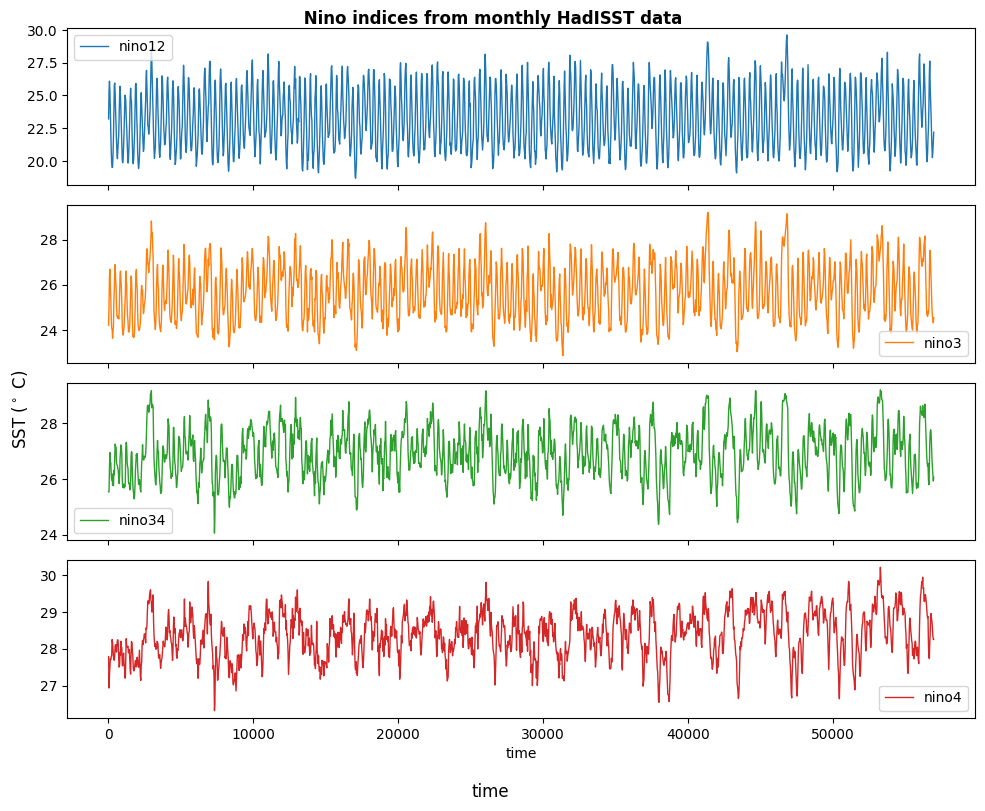

In [16]:
nino_raw.to_dataframe().plot(subplots=True, figsize=(10, 8), lw=1)
plt.gcf().supylabel(r'SST ($^\circ$ C)')
plt.gcf().supxlabel('time')
plt.tight_layout()
plt.gcf().suptitle(' Nino indices from monthly HadISST data',fontsize=12,fontweight='bold',y=0.999)
plt.show()

In [17]:
# %%time
# sst = xr.open_dataset('/gdex/data/d277003/HadISST_sst.nc.gz',engine='netcdf4')

### Compute Nino anomalies #####

## Acknowledgements
- Trenberth, Kevin & National Center for Atmospheric Research Staff (Eds). Last modified 2025-12-11 "The Climate Data Guide: Nino SST Indices (Nino 1+2, 3, 3.4, 4; ONI and TNI).” Retrieved from https://climatedataguide.ucar.edu/climate-data/nino-sst-indices-nino-12-3-34-4-oni-and-tni on 2026-02-25.

In [18]:
cluster.close()